# “Global Cybersecurity Threats Analysis (2015–2024)”
My project is titled **“Global Cybersecurity Threats Analysis (2015–2024)”**. The purpose of this project is to analyze cybersecurity threats recorded between 2015 and 2024 using Python.

I use Python libraries such as Pandas, NumPy, Matplotlib, and Seaborn for data cleaning, analysis, and visualization. The project analyzes different factors such as the year of attack, attack type, affected country, affected industry, attack severity, financial loss, and affected users.

I first load and clean the dataset, check missing and duplicate values, and perform exploratory data analysis. After that, I create different visualizations such as bar charts, line charts, pie charts, scatter plots, box plots, and correlation heatmaps.

The main goal is to identify patterns and trends in global cybersecurity threats, understand which attack types and industries are most affected, and analyze the financial and operational impact of cyberattacks.

The final results provide useful insights into cybersecurity risks and can help organizations understand attack patterns and improve their cybersecurity strategies.


In [1]:
!pip install pandas numpy matplotlib seaborn


[notice] A new release of pip is available: 26.0.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
#Install Required Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

In [4]:
#Put your CSV file in the same folder as your notebook for load the file.
df = pd.read_csv("Global_Cybersecurity_Threats_2015-2024.csv")

In [5]:
#Check whether the dataset loaded correctly:
df.head()

,Country,Year,Attack Type,Target Industry,Financial Loss (in Million $),Number of Affected Users,Attack Source,Security Vulnerability Type,Defense Mechanism Used,Incident Resolution Time (in Hours)
0,China,2019,Phishing,Education,80.53,773169,Hacker Group,Unpatched Software,VPN,63
1,China,2019,Ransomware,Retail,62.19,295961,Hacker Group,Unpatched Software,Firewall,71
2,India,2017,Man-in-the-Middle,IT,38.65,605895,Hacker Group,Weak Passwords,VPN,20
3,UK,2024,Ransomware,Telecommunications,41.44,659320,Nation-state,Social Engineering,AI-based Detection,7
4,Germany,2018,Man-in-the-Middle,IT,74.41,810682,Insider,Social Engineering,VPN,68


In [6]:
#Also check the last rows:
df.tail()

,Country,Year,Attack Type,Target Industry,Financial Loss (in Million $),Number of Affected Users,Attack Source,Security Vulnerability Type,Defense Mechanism Used,Incident Resolution Time (in Hours)
2995,UK,2021,Ransomware,Government,51.42,190694,Unknown,Social Engineering,Firewall,52
2996,Brazil,2023,SQL Injection,Telecommunications,30.28,892843,Hacker Group,Zero-day,VPN,26
2997,Brazil,2017,SQL Injection,IT,32.97,734737,Nation-state,Weak Passwords,AI-based Detection,30
2998,UK,2022,SQL Injection,IT,32.17,379954,Insider,Unpatched Software,Firewall,9
2999,Germany,2021,SQL Injection,Retail,48.20,480984,Unknown,Zero-day,VPN,64


In [7]:
#for understanding the data Check number of rows and columns
df.shape

(3000, 10)

In [8]:
#Check Column Names
df.columns

Index(['Country', 'Year', 'Attack Type', 'Target Industry',
       'Financial Loss (in Million $)', 'Number of Affected Users',
       'Attack Source', 'Security Vulnerability Type',
       'Defense Mechanism Used', 'Incident Resolution Time (in Hours)'],
      dtype='str')

In [9]:
#Check Dataset Information
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 10 columns):
 #   Column                               Non-Null Count  Dtype  
---  ------                               --------------  -----  
 0   Country                              3000 non-null   str    
 1   Year                                 3000 non-null   int64  
 2   Attack Type                          3000 non-null   str    
 3   Target Industry                      3000 non-null   str    
 4   Financial Loss (in Million $)        3000 non-null   float64
 5   Number of Affected Users             3000 non-null   int64  
 6   Attack Source                        3000 non-null   str    
 7   Security Vulnerability Type          3000 non-null   str    
 8   Defense Mechanism Used               3000 non-null   str    
 9   Incident Resolution Time (in Hours)  3000 non-null   int64  
dtypes: float64(1), int64(3), str(6)
memory usage: 234.5 KB


In [10]:
#Check Missing Values Missing data should be checked before visualization.
df.isnull().sum()

Country                                0
Year                                   0
Attack Type                            0
Target Industry                        0
Financial Loss (in Million $)          0
Number of Affected Users               0
Attack Source                          0
Security Vulnerability Type            0
Defense Mechanism Used                 0
Incident Resolution Time (in Hours)    0
dtype: int64

In [11]:
#You can also calculate the percentage of missing values:
(df.isnull().sum() / len(df)) * 100

Country                                0.0
Year                                   0.0
Attack Type                            0.0
Target Industry                        0.0
Financial Loss (in Million $)          0.0
Number of Affected Users               0.0
Attack Source                          0.0
Security Vulnerability Type            0.0
Defense Mechanism Used                 0.0
Incident Resolution Time (in Hours)    0.0
dtype: float64

In [12]:
#Remove Duplicate Records Check duplicates.
df.duplicated().sum()

np.int64(0)

In [13]:
#if duplicates exist
df = df.drop_duplicates()

In [14]:
#For numerical columns:
df.describe()

,Year,Financial Loss (in Million $),Number of Affected Users,Incident Resolution Time (in Hours)
count,3000.000000,3000.000000,3000.000000,3000.000000
mean,2019.570333,50.492970,504684.136333,36.476000
std,2.857932,28.791415,289944.084972,20.570768
min,2015.000000,0.500000,424.000000,1.000000
25%,2017.000000,25.757500,255805.250000,19.000000
50%,2020.000000,50.795000,504513.000000,37.000000
75%,2022.000000,75.630000,758088.500000,55.000000
max,2024.000000,99.990000,999635.000000,72.000000


In [15]:
#Understand Data Types
df.dtypes

Country                                    str
Year                                     int64
Attack Type                                str
Target Industry                            str
Financial Loss (in Million $)          float64
Number of Affected Users                 int64
Attack Source                              str
Security Vulnerability Type                str
Defense Mechanism Used                     str
Incident Resolution Time (in Hours)      int64
dtype: object

In [16]:
df["Year"] = pd.to_numeric(df["Year"], errors="coerce")

In [17]:
df["Year"]

0       2019
1       2019
2       2017
3       2024
4       2018
        ... 
2995    2021
2996    2023
2997    2017
2998    2022
2999    2021
Name: Year, Length: 3000, dtype: int64

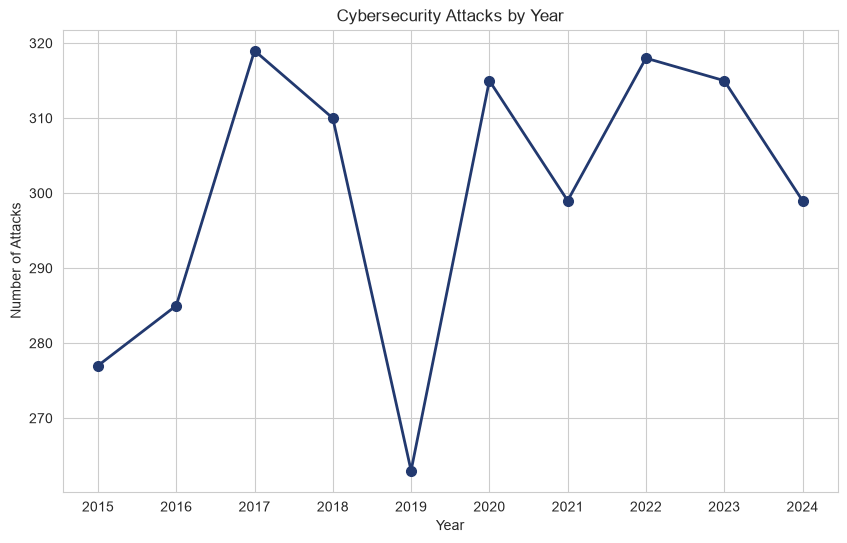

In [54]:
#Visualization 1 — Cyberattacks by Year
yearly_attacks = df["Year"].value_counts().sort_index()

plt.figure(figsize=(10,6))

plt.plot(
    yearly_attacks.index,
    yearly_attacks.values,
    marker="o",
    color="#22396F",
    linewidth=2,
    markersize=7
)

plt.title("Cybersecurity Attacks by Year")
plt.xlabel("Year")
plt.ylabel("Number of Attacks")

plt.xticks(yearly_attacks.index)

plt.show()

It shows whether cybersecurity attacks:

Increased
Decreased
Remained stable

between 2015 and 2024.

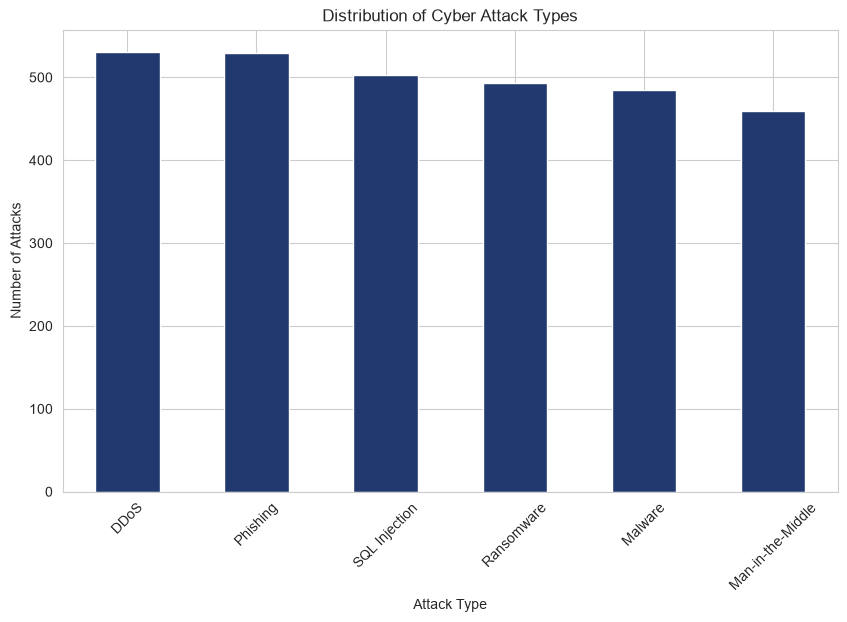

In [55]:
#Visualization 2 — Attack Type Distribution
attack_types = df["Attack Type"].value_counts()
plt.figure(figsize=(10,6))

attack_types.plot(kind="bar",color="#22396F",
)

plt.title("Distribution of Cyber Attack Types")
plt.xlabel("Attack Type")
plt.ylabel("Number of Attacks")

plt.xticks(rotation=45)
plt.show()

This identifies the most common cybersecurity attack types.

For example, your dataset may contain categories such as:

DDoS
Malware
Phishing
Ransomware
Data Breach

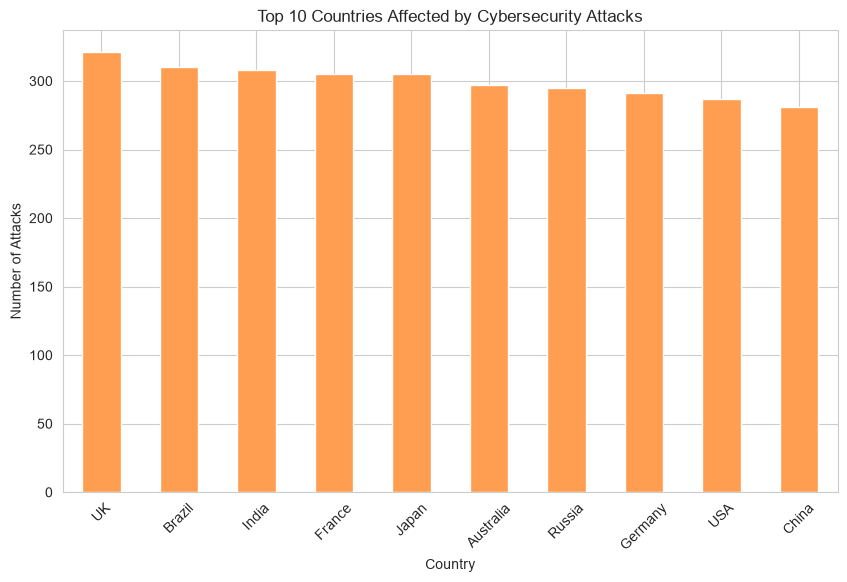

In [57]:
#Visualization 3 — Top Countries Affected
country_counts = df["Country"].value_counts().head(10)

plt.figure(figsize=(10,6))

country_counts.plot(kind="bar",color="#FF9D50")

plt.title("Top 10 Countries Affected by Cybersecurity Attacks")
plt.xlabel("Country")
plt.ylabel("Number of Attacks")

plt.xticks(rotation=45)
plt.show()

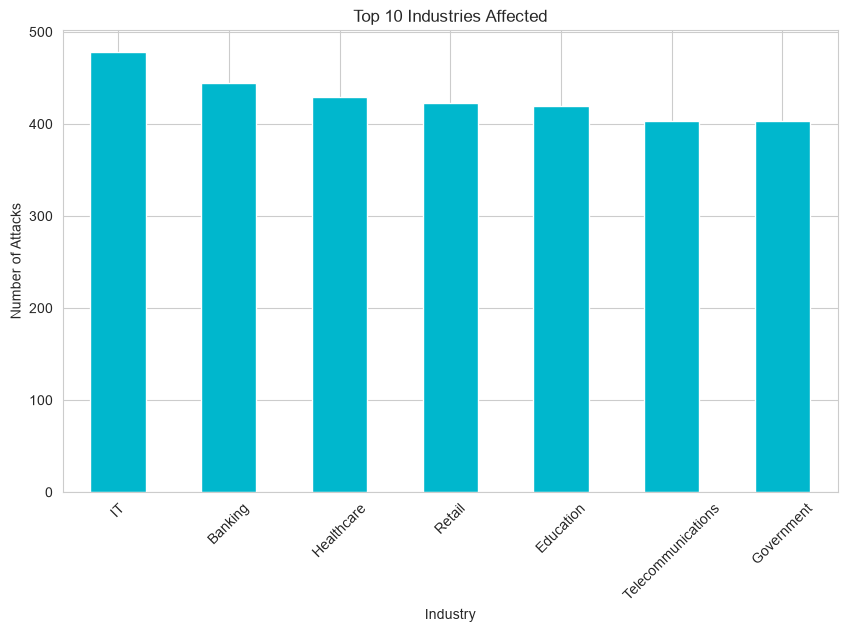

In [58]:
#Visualization 4 — Most Affected Industries
industry_counts = df["Target Industry"].value_counts().head(10)

plt.figure(figsize=(10,6))

industry_counts.plot(kind="bar",color="#00B7CD")

plt.title("Top 10 Industries Affected")
plt.xlabel("Industry")
plt.ylabel("Number of Attacks")

plt.xticks(rotation=45)
plt.show()

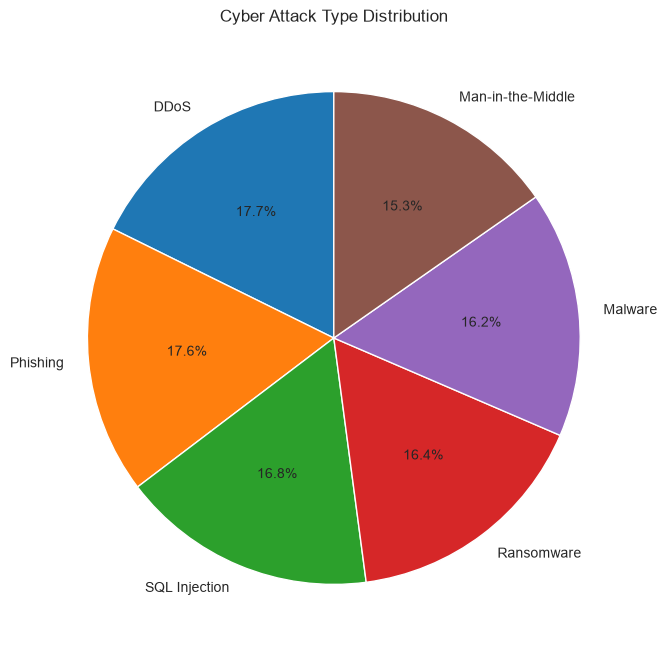

In [28]:
#Visualization 5 — Attack Type Pie Chart
attack_types = df["Attack Type"].value_counts()

plt.figure(figsize=(8,8))

plt.pie(
    attack_types.values,
    labels=attack_types.index,
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Cyber Attack Type Distribution")

plt.show()

In [30]:
#Visualization 6 — Financial Loss by Year
financial_loss = df.groupby("Year")["Financial Loss (in Million $)"].sum()

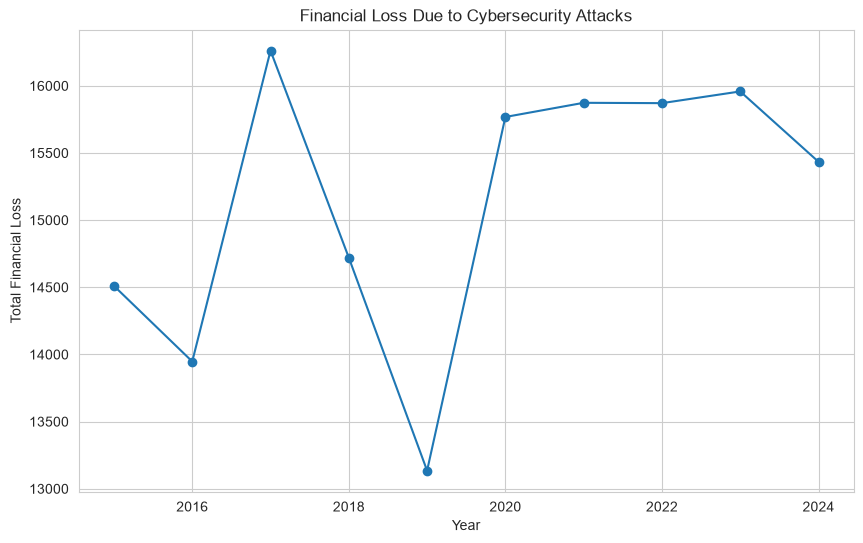

In [31]:
plt.figure(figsize=(10,6))

plt.plot(
    financial_loss.index,
    financial_loss.values,
    marker="o"
)

plt.title("Financial Loss Due to Cybersecurity Attacks")
plt.xlabel("Year")
plt.ylabel("Total Financial Loss")

plt.show()

In [33]:
#Visualization 7 — Attack Severity Distribution
severity_counts = df["Attack Source"].value_counts()

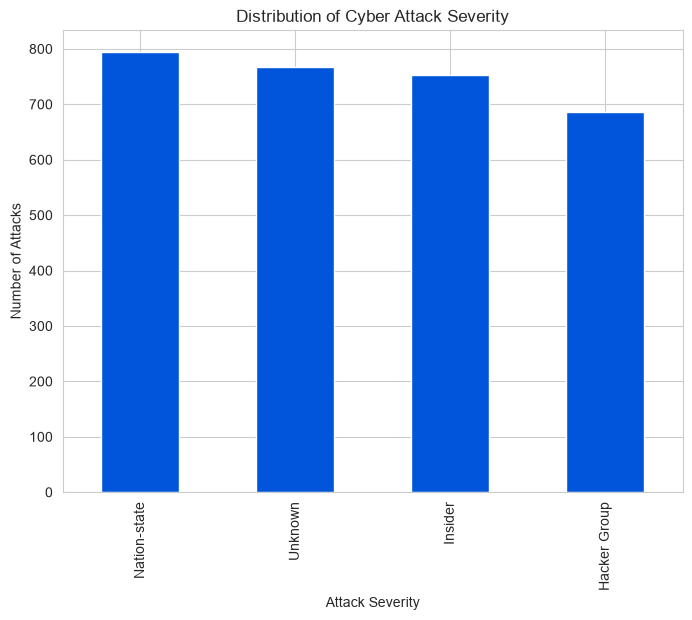

In [59]:
plt.figure(figsize=(8,6))

severity_counts.plot(kind="bar",color="#0055DA")

plt.title("Distribution of Cyber Attack Severity")
plt.xlabel("Attack Severity")
plt.ylabel("Number of Attacks")

plt.show()

In [35]:
#Visualization 8 — Heatmap
numeric_df = df.select_dtypes(include=np.number)

In [36]:
correlation = numeric_df.corr()

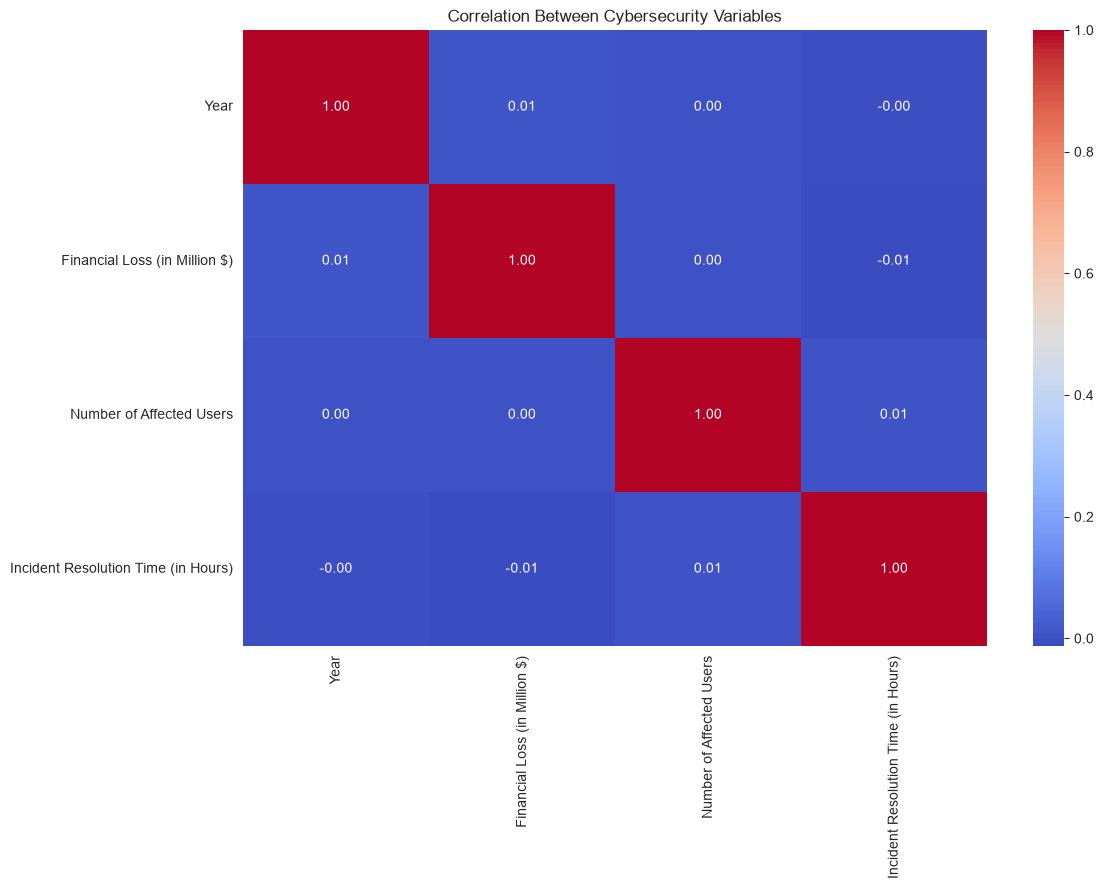

In [37]:
plt.figure(figsize=(12,8))

sns.heatmap(
    correlation,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Between Cybersecurity Variables")

plt.show()

In [39]:
#Visualization 9 — Industry vs Attack Type
industry_attack = pd.crosstab(
    df["Target Industry"],
    df["Attack Type"]
)

In [41]:
top_industries = df["Target Industry"].value_counts().head(10).index

industry_attack_top = industry_attack.loc[top_industries]

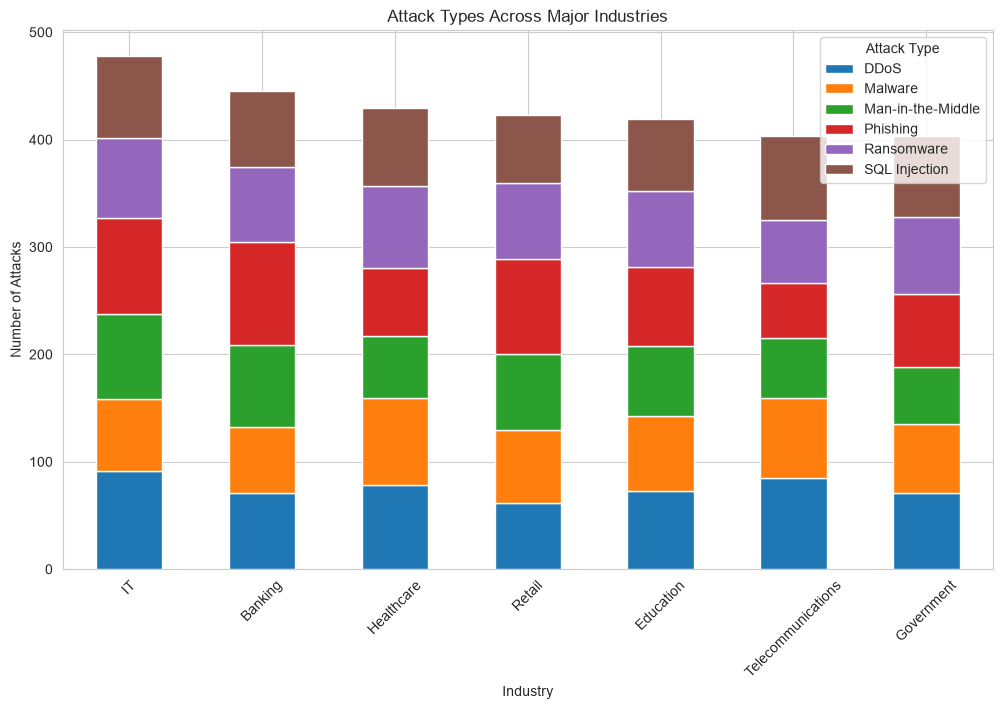

In [42]:
industry_attack_top.plot(
    kind="bar",
    stacked=True,
    figsize=(12,7)
)

plt.title("Attack Types Across Major Industries")
plt.xlabel("Industry")
plt.ylabel("Number of Attacks")

plt.xticks(rotation=45)

plt.legend(title="Attack Type")

plt.show()

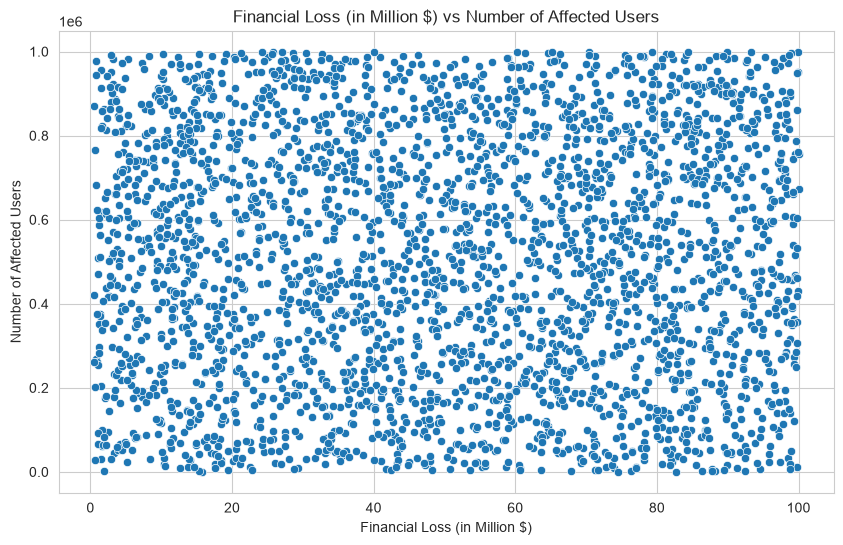

In [45]:
#Visualization 10 — Scatter Plot---If you have two numerical columns, such as:
#Financial Loss
#Affected Users
#you can investigate their relationship.
plt.figure(figsize=(10,6))

sns.scatterplot(
    data=df,
    x="Financial Loss (in Million $)",
    y="Number of Affected Users"
)

plt.title("Financial Loss (in Million $) vs Number of Affected Users")
plt.xlabel("Financial Loss (in Million $)")
plt.ylabel("Number of Affected Users")

plt.show()

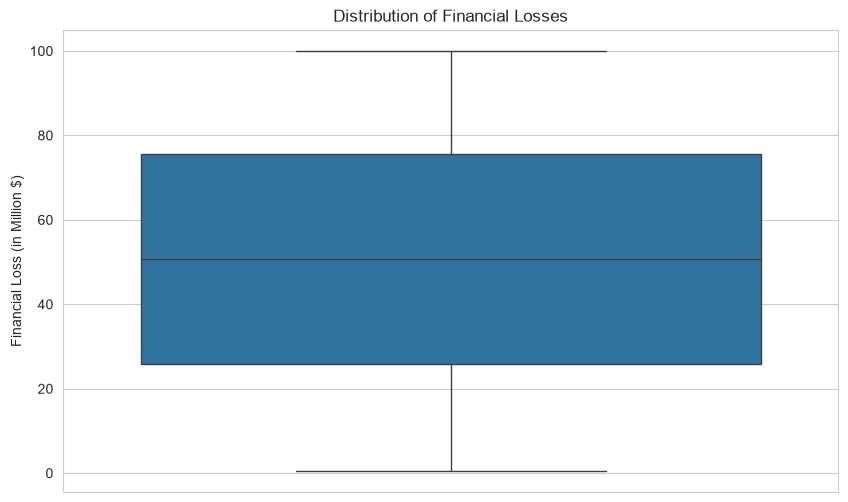

In [61]:
#Visualization 11 — Box Plot
plt.figure(figsize=(10,6))

sns.boxplot(
    y=df["Financial Loss (in Million $)"]
)

plt.title("Distribution of Financial Losses")
plt.ylabel("Financial Loss (in Million $)")

plt.show()

In [48]:
#Create a Summary Table
summary = df.groupby("Year").agg(
    Total_Attacks=("Year", "count"),
    Average_Loss=("Financial Loss (in Million $)", "mean"),
    Total_Loss=("Financial Loss (in Million $)", "sum")
)

summary

,Total_Attacks,Average_Loss,Total_Loss
Year,,,
2015,277,52.383430,14510.21
2016,285,48.937754,13947.26
2017,319,50.977053,16261.68
2018,310,47.485419,14720.48
2019,263,49.941787,13134.69
2020,315,50.056984,15767.95
2021,299,53.088328,15873.41
2022,318,49.908365,15870.86
2023,315,50.660571,15958.08


In [50]:
#At the beginning or end of your notebook, you can display key KPIs.
total_attacks = len(df)
total_countries = df["Country"].nunique()
total_attack_types = df["Attack Type"].nunique()
total_industries = df["Target Industry"].nunique()

print("Cybersecurity Threat Analysis")
print("------------------------------")
print("Total Attacks:", total_attacks)
print("Countries Affected:", total_countries)
print("Attack Types:", total_attack_types)
print("Industries Affected:", total_industries)

Cybersecurity Threat Analysis
------------------------------
Total Attacks: 3000
Countries Affected: 10
Attack Types: 6
Industries Affected: 7
